<a href="https://colab.research.google.com/github/Claud1601/CN7030-Assignment/blob/main/Group_22_CRWK_CN7030_Forest_CoverType.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning on Big Data (CN7030) CRWK

## Group ID: [Your Group ID]

1. **Student 1:** [Name and ID]  
2. **Student 2:** [Name and ID]  
3. **Student 3:** [Name and ID, if applicable]  
4. **Student 4:** [Name and ID, if applicable]

**Project Title:** Multiclass Forest Cover Type Prediction Using Ensemble Machine Learning with PySpark

> If you want to add comments on your group work, please write them here:
>
> [Add group comments here]


## Initiate and Configure Spark


In [1]:
 # ============================================================
# CN7030 - Machine Learning on Big Data
# Forest CoverType Multiclass Classification
# ============================================================

!pip install pyspark -q

from pyspark.sql import SparkSession

# Stop any existing SparkSession to prevent connection issues
if 'spark' in locals() and spark.sparkContext._jsc is not None:
    spark.stop()

spark = (
    SparkSession.builder
    .appName("CN7030_Forest_CoverType")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")  # Increased driver memory
    .config("spark.executor.memory", "4g") # Increased executor memory
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark Version:", spark.version)
print("Application Name:", spark.sparkContext.appName)
print("Default Parallelism:", spark.sparkContext.defaultParallelism)

Spark Version: 4.0.4
Application Name: CN7030_Forest_CoverType
Default Parallelism: 2


# Task 1 Data chosen and Research objectives (10 Marks)

### 1.1 Selected Dataset

The dataset selected for this project is the **Forest CoverType dataset**. The objective is to predict the dominant forest cover type of a geographical area using cartographic and environmental attributes.

The dataset contains approximately **581,012 observations**, 54 predictor variables and one multiclass target variable named `Cover_Type`.

The target contains seven forest-cover classes:

1. Spruce/Fir
2. Lodgepole Pine
3. Ponderosa Pine
4. Cottonwood/Willow
5. Aspen
6. Douglas-fir
7. Krummholz

The predictor variables contain elevation, slope, aspect, hydrological distances, road distance, hillshade measurements, fire-point distance, wilderness-area indicators and soil-type indicators.

Although the dataset is smaller than some modern terabyte-scale big-data datasets, it contains more than half a million observations and 54 predictor variables. The complete machine-learning workflow is therefore implemented using PySpark DataFrames and Spark ML so that the same pipeline can scale to larger distributed datasets without redesigning the analysis.

### 1.2 Dataset Variables

The dataset contains ten quantitative cartographic attributes:

- `Elevation` - elevation of the geographical cell in metres.
- `Aspect` - direction of slope in degrees.
- `Slope` - slope steepness in degrees.
- `Horizontal_Distance_To_Hydrology` - horizontal distance to the nearest surface-water feature.
- `Vertical_Distance_To_Hydrology` - vertical distance to the nearest surface-water feature.
- `Horizontal_Distance_To_Roadways` - horizontal distance to the nearest roadway.
- `Hillshade_9am` - hillshade index measured at 9:00 AM.
- `Hillshade_Noon` - hillshade index measured at noon.
- `Hillshade_3pm` - hillshade index measured at 3:00 PM.
- `Horizontal_Distance_To_Fire_Points` - horizontal distance to the nearest wildfire ignition point.

Four binary wilderness-area variables are included:

- `Wilderness_Area1`
- `Wilderness_Area2`
- `Wilderness_Area3`
- `Wilderness_Area4`

A value of 1 indicates that the observation belongs to the corresponding wilderness area, whereas 0 indicates that it does not.

Forty binary soil-type variables are provided: `Soil_Type1` through `Soil_Type40`.

Each soil variable is one-hot encoded. A value of 1 indicates the presence of that soil type for the geographical observation and 0 indicates its absence.

The dependent variable is:

- `Cover_Type` - multiclass target variable containing values from 1 to 7.

### 1.3 Research Questions

**RQ1:** How accurately can forest cover type be predicted from cartographic and environmental variables using PySpark machine-learning algorithms?

**RQ2:** Does a Random Forest ensemble classifier provide better multiclass prediction performance than a single Decision Tree classifier?

**RQ3:** To what extent does hyperparameter optimisation improve the performance of the Random Forest model?

**RQ4:** How does class imbalance affect model performance, particularly for minority forest-cover classes?

**RQ5:** Which environmental and geographical variables contribute most to prediction of forest cover type?

**RQ6:** How stable and reproducible is the final machine-learning model across multiple random train-test splits?

### 1.4 Research Objectives

1. To load and process the Forest CoverType dataset using PySpark DataFrames.
2. To investigate missing values, duplicate observations and class imbalance.
3. To develop a multiclass Decision Tree classifier as a baseline model.
4. To develop a Random Forest classifier to demonstrate ensemble learning.
5. To optimise model hyperparameters using Spark ML model-selection techniques.
6. To evaluate the models using accuracy, F1-score, precision, recall and a multiclass confusion matrix.
7. To investigate model bias and variance.
8. To evaluate model reproducibility by reporting mean performance and standard deviation.
9. To identify the most influential predictor variables.
10. To discuss relevant Legal, Social, Ethical and Professional issues.

### 1.5 Proposed Big Data PySpark Pipeline

```text
Raw Forest CoverType Data
        ↓
Spark DataFrame
        ↓
Schema and Data Quality Analysis
        ↓
Missing-Value Analysis
        ↓
Duplicate Analysis
        ↓
Class Distribution Analysis
        ↓
Label Transformation
        ↓
VectorAssembler
        ↓
Train/Test Split
        ↓
Decision Tree Baseline
        ↓
Random Forest Ensemble
        ↓
Hyperparameter Optimisation
        ↓
Multiclass Prediction
        ↓
Accuracy / Precision / Recall / F1
        ↓
Confusion Matrix
        ↓
Repeated Experiments
        ↓
Mean ± Standard Deviation
        ↓
Feature Importance
        ↓
Results and LSEP Analysis
```


# Task 2 - Data Loading and Preprocessing & Visualisation (15 marks)


In [2]:
# Identify the students who made contributions and mention their names here.
# Contributors:
# Student 1: [Name - Student ID]
# Student 2: [Name - Student ID]

import urllib.request
import os
import pandas as pd
import matplotlib.pyplot as plt

dataset_url = "https://kdd.ics.uci.edu/databases/covertype/covtype.data.gz"
dataset_path = "/content/covtype.data.gz"

if not os.path.exists(dataset_path):
    urllib.request.urlretrieve(dataset_url, dataset_path)

print("Dataset successfully downloaded.")
print("Dataset location:", dataset_path)


Dataset successfully downloaded.
Dataset location: /content/covtype.data.gz


In [3]:
# Define the dataset column names

quantitative_cols = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

wilderness_cols = [
    "Wilderness_Area1",
    "Wilderness_Area2",
    "Wilderness_Area3",
    "Wilderness_Area4"
]

soil_cols = [f"Soil_Type{i}" for i in range(1, 41)]

feature_cols = quantitative_cols + wilderness_cols + soil_cols
all_columns = feature_cols + ["Cover_Type"]

print("Predictor variables:", len(feature_cols))
print("Total columns:", len(all_columns))


Predictor variables: 54
Total columns: 55


In [4]:
# Load the raw dataset using a PySpark DataFrame

df = (
    spark.read
    .option("header", "false")
    .option("inferSchema", "true")
    .csv(dataset_path)
)

df = df.toDF(*all_columns)

print("Dataset loaded successfully.")
df.show(5)


Dataset loaded successfully.
+---------+------+-----+--------------------------------+------------------------------+-------------------------------+-------------+--------------+-------------+----------------------------------+----------------+----------------+----------------+----------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----------+
|Elevation|Aspect|Slope|Horizontal_Distance_To_Hydrology|Vertical_Distance_To_Hydrology|Horizontal_Distance_To_Roadways|Hillshade_9am|Hillshade_Noon|Hillshade_3pm|Horizontal_Distance_To_Fire_Points|Wilderness_Area1|Wildern

In [5]:
# Dataset dimensions and schema

row_count = df.count()
column_count = len(df.columns)

print("Number of rows:", row_count)
print("Number of columns:", column_count)

df.printSchema()


Number of rows: 581012
Number of columns: 55
root
 |-- Elevation: integer (nullable = true)
 |-- Aspect: integer (nullable = true)
 |-- Slope: integer (nullable = true)
 |-- Horizontal_Distance_To_Hydrology: integer (nullable = true)
 |-- Vertical_Distance_To_Hydrology: integer (nullable = true)
 |-- Horizontal_Distance_To_Roadways: integer (nullable = true)
 |-- Hillshade_9am: integer (nullable = true)
 |-- Hillshade_Noon: integer (nullable = true)
 |-- Hillshade_3pm: integer (nullable = true)
 |-- Horizontal_Distance_To_Fire_Points: integer (nullable = true)
 |-- Wilderness_Area1: integer (nullable = true)
 |-- Wilderness_Area2: integer (nullable = true)
 |-- Wilderness_Area3: integer (nullable = true)
 |-- Wilderness_Area4: integer (nullable = true)
 |-- Soil_Type1: integer (nullable = true)
 |-- Soil_Type2: integer (nullable = true)
 |-- Soil_Type3: integer (nullable = true)
 |-- Soil_Type4: integer (nullable = true)
 |-- Soil_Type5: integer (nullable = true)
 |-- Soil_Type6: integ

In [6]:
# Descriptive statistics for the quantitative predictors

df.select(quantitative_cols).describe().show()


+-------+-----------------+------------------+------------------+--------------------------------+------------------------------+-------------------------------+------------------+------------------+------------------+----------------------------------+
|summary|        Elevation|            Aspect|             Slope|Horizontal_Distance_To_Hydrology|Vertical_Distance_To_Hydrology|Horizontal_Distance_To_Roadways|     Hillshade_9am|    Hillshade_Noon|     Hillshade_3pm|Horizontal_Distance_To_Fire_Points|
+-------+-----------------+------------------+------------------+--------------------------------+------------------------------+-------------------------------+------------------+------------------+------------------+----------------------------------+
|  count|           581012|            581012|            581012|                          581012|                        581012|                         581012|            581012|            581012|            581012|                    

In [7]:
# Missing-value analysis

from pyspark.sql.functions import col, sum as spark_sum

missing_df = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

print("Missing Values")
missing_df.show(vertical=True)


Missing Values
-RECORD 0---------------------------------
 Elevation                          | 0   
 Aspect                             | 0   
 Slope                              | 0   
 Horizontal_Distance_To_Hydrology   | 0   
 Vertical_Distance_To_Hydrology     | 0   
 Horizontal_Distance_To_Roadways    | 0   
 Hillshade_9am                      | 0   
 Hillshade_Noon                     | 0   
 Hillshade_3pm                      | 0   
 Horizontal_Distance_To_Fire_Points | 0   
 Wilderness_Area1                   | 0   
 Wilderness_Area2                   | 0   
 Wilderness_Area3                   | 0   
 Wilderness_Area4                   | 0   
 Soil_Type1                         | 0   
 Soil_Type2                         | 0   
 Soil_Type3                         | 0   
 Soil_Type4                         | 0   
 Soil_Type5                         | 0   
 Soil_Type6                         | 0   
 Soil_Type7                         | 0   
 Soil_Type8                         | 0

### Missing-Value Interpretation

Inspect the output above before final submission. If all values are zero, the following interpretation is appropriate:

> A distributed missing-value analysis was performed across all variables using PySpark. No missing observations were identified. Therefore, imputation was not required and all observations were retained for subsequent modelling.


In [8]:
# Duplicate analysis

original_rows = df.count()
unique_rows = df.dropDuplicates().count()
duplicates = original_rows - unique_rows

print("Original rows:", original_rows)
print("Unique rows:", unique_rows)
print("Duplicate rows:", duplicates)


Original rows: 581012
Unique rows: 581012
Duplicate rows: 0


In [9]:
# Class distribution and imbalance analysis

from pyspark.sql.functions import round as spark_round

class_distribution = (
    df.groupBy("Cover_Type")
    .count()
    .orderBy("Cover_Type")
)

total = df.count()

class_distribution = class_distribution.withColumn(
    "Percentage",
    spark_round((col("count") / total) * 100, 2)
)

class_distribution.show()


+----------+------+----------+
|Cover_Type| count|Percentage|
+----------+------+----------+
|         1|211840|     36.46|
|         2|283301|     48.76|
|         3| 35754|      6.15|
|         4|  2747|      0.47|
|         5|  9493|      1.63|
|         6| 17367|      2.99|
|         7| 20510|      3.53|
+----------+------+----------+



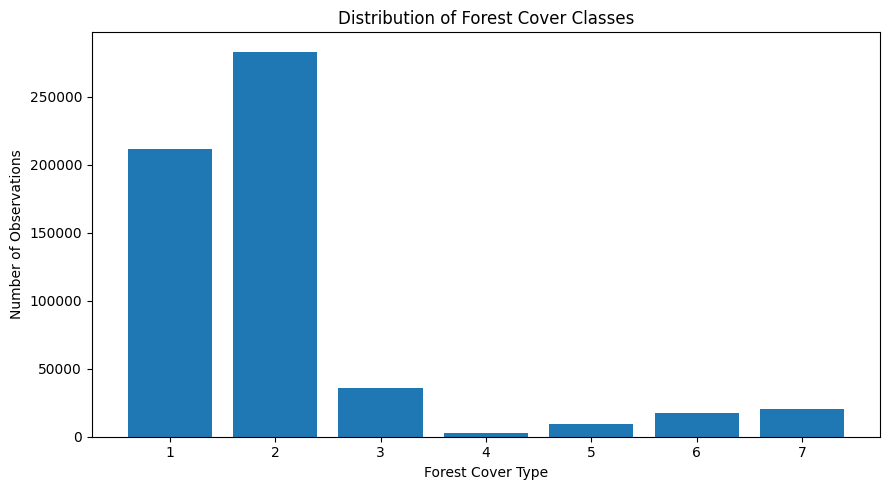

In [10]:
# Visualise class distribution

class_pd = class_distribution.toPandas()

plt.figure(figsize=(9, 5))
plt.bar(
    class_pd["Cover_Type"].astype(str),
    class_pd["count"]
)
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Observations")
plt.title("Distribution of Forest Cover Classes")
plt.tight_layout()
plt.show()


### Class-Imbalance Analysis

The class-distribution analysis demonstrates that the target variable is imbalanced. Some forest-cover categories occur substantially more frequently than others. Therefore, overall accuracy alone is insufficient for model evaluation. Weighted precision, weighted recall, F1-score and class-specific performance are also considered.

The proposed mitigation strategy is to evaluate minority-class behaviour explicitly using per-class precision and recall and to compare the standard Random Forest with a class-weighted Random Forest. This avoids relying only on overall accuracy.


In [11]:
# Convert labels from 1-7 to 0-6 for Spark ML

df = df.withColumn(
    "label",
    (col("Cover_Type") - 1).cast("double")
)

df.select("Cover_Type", "label").show(10)


+----------+-----+
|Cover_Type|label|
+----------+-----+
|         5|  4.0|
|         5|  4.0|
|         2|  1.0|
|         2|  1.0|
|         5|  4.0|
|         2|  1.0|
|         5|  4.0|
|         5|  4.0|
|         5|  4.0|
|         5|  4.0|
+----------+-----+
only showing top 10 rows


In [12]:
# Assemble all 54 predictors into a single features vector

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

model_df = assembler.transform(df)

# Keep target, label and feature vector
model_df = model_df.select(
    "features",
    "label",
    "Cover_Type"
)

model_df.cache()

print("Cached observations:", model_df.count())
model_df.show(5, truncate=False)


Cached observations: 581012
+--------------------------------------------------------------------------------------------------------+-----+----------+
|features                                                                                                |label|Cover_Type|
+--------------------------------------------------------------------------------------------------------+-----+----------+
|(54,[0,1,2,3,5,6,7,8,9,10,42],[2596.0,51.0,3.0,258.0,510.0,221.0,232.0,148.0,6279.0,1.0,1.0])           |4.0  |5         |
|(54,[0,1,2,3,4,5,6,7,8,9,10,42],[2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,1.0,1.0])    |4.0  |5         |
|(54,[0,1,2,3,4,5,6,7,8,9,10,25],[2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,1.0,1.0])  |1.0  |2         |
|(54,[0,1,2,3,4,5,6,7,8,9,10,43],[2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,1.0,1.0])|1.0  |2         |
|(54,[0,1,2,3,4,5,6,7,8,9,10,42],[2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,1.0,1.0])   

### Feature Scaling Decision

Feature standardisation is not applied to the main Decision Tree and Random Forest models. Tree-based algorithms split features using threshold rules and therefore do not require the predictors to be on the same numerical scale.


In [13]:
# Reproducible 80/20 train-test split

train_df, test_df = model_df.randomSplit(
    [0.80, 0.20],
    seed=42
)

train_df.cache()
test_df.cache()

print("Training samples:", train_df.count())
print("Testing samples:", test_df.count())


Training samples: 464787
Testing samples: 116225


In [14]:
# Create inverse-frequency class weights for an additional imbalance-aware model

train_total = train_df.count()
num_classes = 7

class_counts_train = train_df.groupBy("label").count()

weights_df = class_counts_train.withColumn(
    "classWeight",
    train_total / (num_classes * col("count"))
).select("label", "classWeight")

weighted_train_df = train_df.join(
    weights_df,
    on="label",
    how="left"
)

print("Class weights:")
weights_df.orderBy("label").show()

weighted_train_df.select("label", "classWeight").show(10)


Class weights:
+-----+-------------------+
|label|        classWeight|
+-----+-------------------+
|  0.0|0.39267930011912505|
|  1.0| 0.2926523812042403|
|  2.0| 2.3209641658676894|
|  3.0|  30.04440853264383|
|  4.0|  8.656863475507544|
|  5.0|  4.788903199216938|
|  6.0| 4.0339090435688245|
+-----+-------------------+

+-----+------------------+
|label|       classWeight|
+-----+------------------+
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
|  1.0|0.2926523812042403|
+-----+------------------+
only showing top 10 rows


# Task 3 - Model Selection and Implementation (15 marks)


### Student 1: [Name - Student ID]

#### Decision Tree Baseline

A Decision Tree classifier is used as the baseline model. It can capture nonlinear relationships and provides a useful comparison against the Random Forest ensemble. A single tree can, however, have relatively high variance and may overfit the training data.


In [15]:
# Student 1: [Name - Student ID]
# Decision Tree Classifier

from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=10,
    seed=42
)

dt_model = dt.fit(train_df)
dt_predictions = dt_model.transform(test_df)

dt_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
|  1.0|       1.0|[0.09857297038014...|
+-----+----------+--------------------+
only showing top 10 rows


### Student 2: [Name - Student ID]

#### Random Forest Ensemble Model

Random Forest is selected as the main ensemble-learning algorithm. Instead of relying on one Decision Tree, it combines predictions from multiple trees. This ensemble mechanism can improve generalisation and reduce the variance associated with an individual tree.


In [16]:
# Student 2: [Name - Student ID]
# Random Forest Classifier

from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=80,
    maxDepth=15,
    maxBins=64,
    seed=42
)

rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  1.0|       1.0|[0.19297304071291...|
|  1.0|       1.0|[0.20078345680980...|
|  1.0|       1.0|[0.19248450727329...|
|  1.0|       1.0|[0.18354245280704...|
|  1.0|       1.0|[0.20273967707757...|
|  1.0|       1.0|[0.20434992001059...|
|  1.0|       1.0|[0.17975611701556...|
|  1.0|       1.0|[0.19987130243567...|
|  1.0|       1.0|[0.18741760906879...|
|  1.0|       1.0|[0.18884865408774...|
+-----+----------+--------------------+
only showing top 10 rows


In [17]:
# Additional imbalance-aware Random Forest using class weights

weighted_rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="classWeight",
    numTrees=80,
    maxDepth=15,
    maxBins=64,
    seed=42
)

weighted_rf_model = weighted_rf.fit(weighted_train_df)

weighted_rf_predictions = weighted_rf_model.transform(test_df)

weighted_rf_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  1.0|       1.0|[0.23321600660281...|
|  1.0|       1.0|[0.24923097566727...|
|  1.0|       1.0|[0.25317471321922...|
|  1.0|       1.0|[0.23264753090823...|
|  1.0|       1.0|[0.24690459874083...|
|  1.0|       1.0|[0.23891038138209...|
|  1.0|       1.0|[0.22299064768700...|
|  1.0|       1.0|[0.25222259138710...|
|  1.0|       1.0|[0.21722499976006...|
|  1.0|       1.0|[0.23293240248747...|
+-----+----------+--------------------+
only showing top 10 rows


# Task 4 - Model Parameter Tuning (20 marks)


### Student 1: [Name - Student ID] — Decision Tree Hyperparameter Tuning


In [18]:
# Student 1: [Name - Student ID]
# Decision Tree Hyperparameter Tuning

from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

dt_tuning = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    seed=42
)

dt_param_grid = (
    ParamGridBuilder()
    .addGrid(dt_tuning.maxDepth, [5, 10, 15])
    .addGrid(dt_tuning.maxBins, [32, 64])
    .build()
)

print("Decision Tree parameter combinations:", len(dt_param_grid))

dt_tvs = TrainValidationSplit(
    estimator=dt_tuning,
    estimatorParamMaps=dt_param_grid,
    evaluator=f1_evaluator,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

dt_tvs_model = dt_tvs.fit(train_df)
best_dt_model = dt_tvs_model.bestModel

print("Best Decision Tree parameters:")
print(best_dt_model.extractParamMap())


Decision Tree parameter combinations: 6
Best Decision Tree parameters:
{Param(parent='DecisionTreeClassifier_3b0e9f01a962', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='DecisionTreeClassifier_3b0e9f01a962', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10, Param(parent='DecisionTreeClassifier_3b0e9f01a962', name='featuresCol', doc='features column name.'): 'features', Param(parent='DecisionTreeClassifier_3b0e9f01a962', name='impurity', doc='Criterion used for information gain calc

### Student 2: [Name - Student ID] — Random Forest Hyperparameter Tuning


In [19]:
# Student 2: [Name - Student ID]
# Random Forest Hyperparameter Tuning

rf_tuning = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    seed=42
)

rf_param_grid = (
    ParamGridBuilder()
    .addGrid(rf_tuning.numTrees, [50, 100])
    .addGrid(rf_tuning.maxDepth, [10, 15])
    .addGrid(rf_tuning.maxBins, [32, 64])
    .build()
)

print("Random Forest parameter combinations:", len(rf_param_grid))

rf_tvs = TrainValidationSplit(
    estimator=rf_tuning,
    estimatorParamMaps=rf_param_grid,
    evaluator=f1_evaluator,
    trainRatio=0.8,
    parallelism=2,
    seed=42
)

rf_tvs_model = rf_tvs.fit(train_df)
best_rf_model = rf_tvs_model.bestModel

print("Best Random Forest parameters:")
print(best_rf_model.extractParamMap())


Random Forest parameter combinations: 8
Best Random Forest parameters:
{Param(parent='RandomForestClassifier_9cde5b755c94', name='bootstrap', doc='Whether bootstrap samples are used when building trees.'): True, Param(parent='RandomForestClassifier_9cde5b755c94', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='RandomForestClassifier_9cde5b755c94', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10, Param(parent='RandomForestClassifier_9cde5b755c94', name='featureSubsetStrategy', doc="T

### Hyperparameter-Tuning Rationale

The parameter grid is deliberately compact to keep the experiment computationally practical while still testing model-complexity parameters.

For the Decision Tree, `maxDepth` and `maxBins` are tuned.

For the Random Forest, `numTrees`, `maxDepth` and `maxBins` are tuned. F1-score is used as the model-selection metric because the target classes are imbalanced.

`TrainValidationSplit` is used as a computationally efficient first-stage tuning approach. A larger k-fold `CrossValidator` can be used if additional runtime is available.


# Task 5 - Model Evaluation and Accuracy Calculation (20 marks)


In [20]:
# Common multiclass evaluation function

def evaluate_predictions(predictions):
    results = {}

    metrics = [
        "accuracy",
        "f1",
        "weightedPrecision",
        "weightedRecall"
    ]

    for metric in metrics:
        evaluator = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName=metric
        )
        results[metric] = evaluator.evaluate(predictions)

    return results


### Student 1: [Name - Student ID] — Tuned Decision Tree Evaluation


In [21]:
# Student 1: [Name - Student ID]

best_dt_predictions = dt_tvs_model.transform(test_df)
dt_results = evaluate_predictions(best_dt_predictions)

print("Tuned Decision Tree Results")
print("-" * 35)

for metric, value in dt_results.items():
    print(f"{metric}: {value:.4f}")


Tuned Decision Tree Results
-----------------------------------
accuracy: 0.8528
f1: 0.8509
weightedPrecision: 0.8533
weightedRecall: 0.8528


### Student 2: [Name - Student ID] — Tuned Random Forest Evaluation


In [22]:
# Student 2: [Name - Student ID]

best_rf_predictions = rf_tvs_model.transform(test_df)
rf_results = evaluate_predictions(best_rf_predictions)

print("Tuned Random Forest Results")
print("-" * 35)

for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")


Tuned Random Forest Results
-----------------------------------
accuracy: 0.7914
f1: 0.7834
weightedPrecision: 0.7969
weightedRecall: 0.7914


In [23]:
# Evaluate the imbalance-aware Random Forest for comparison

weighted_rf_results = evaluate_predictions(weighted_rf_predictions)

print("Weighted Random Forest Results")
print("-" * 35)

for metric, value in weighted_rf_results.items():
    print(f"{metric}: {value:.4f}")


Weighted Random Forest Results
-----------------------------------
accuracy: 0.7494
f1: 0.7632
weightedPrecision: 0.8030
weightedRecall: 0.7494


### Evaluation Metrics

The following multiclass evaluation measures are reported:

- **Accuracy:** proportion of all test observations classified correctly.
- **Weighted Precision:** precision averaged across classes according to class frequency.
- **Weighted Recall:** recall averaged across classes according to class frequency.
- **F1-score:** harmonic mean of precision and recall.

Because the target classes are imbalanced, accuracy is interpreted together with F1-score, weighted metrics and class-specific results.


In [24]:
# Confusion matrix counts for the tuned Random Forest

confusion_df = (
    best_rf_predictions
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)

confusion_df.show(100)


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|32579|
|  0.0|       1.0| 9985|
|  0.0|       2.0|    4|
|  0.0|       6.0|  182|
|  1.0|       0.0| 7325|
|  1.0|       1.0|48635|
|  1.0|       2.0|  355|
|  1.0|       3.0|    1|
|  1.0|       4.0|   18|
|  1.0|       5.0|   55|
|  1.0|       6.0|   28|
|  2.0|       1.0|  747|
|  2.0|       2.0| 6287|
|  2.0|       3.0|   19|
|  2.0|       5.0|   93|
|  3.0|       2.0|  204|
|  3.0|       3.0|  325|
|  3.0|       5.0|    8|
|  4.0|       0.0|   11|
|  4.0|       1.0| 1529|
|  4.0|       2.0|   53|
|  4.0|       4.0|  230|
|  5.0|       1.0|  992|
|  5.0|       2.0| 1387|
|  5.0|       3.0|   16|
|  5.0|       5.0| 1107|
|  6.0|       0.0| 1207|
|  6.0|       1.0|   28|
|  6.0|       6.0| 2815|
+-----+----------+-----+



In [25]:
# Per-class precision and recall

per_class_results = []

for class_id in range(7):
    precision_evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="precisionByLabel",
        metricLabel=float(class_id)
    )

    recall_evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="recallByLabel",
        metricLabel=float(class_id)
    )

    precision = precision_evaluator.evaluate(best_rf_predictions)
    recall = recall_evaluator.evaluate(best_rf_predictions)

    per_class_results.append({
        "Cover Type": class_id + 1,
        "Precision": precision,
        "Recall": recall
    })

per_class_pd = pd.DataFrame(per_class_results)
per_class_pd


,Cover Type,Precision,Recall
0,1,0.792252,0.762082
1,2,0.785500,0.862063
2,3,0.758384,0.879793
3,4,0.900277,0.605214
4,5,0.927419,0.126166
5,6,0.876485,0.316105
6,7,0.930579,0.695062


### Reproducibility Requirement

The final Random Forest configuration is run five times using fixed, pre-defined random seeds. Mean and standard deviation are reported so that the final result represents both average predictive performance and model stability rather than a single random split.


In [26]:
# Extract selected Random Forest parameters robustly

best_num_trees = best_rf_model.getOrDefault(best_rf_model.numTrees)
best_max_depth = best_rf_model.getOrDefault(best_rf_model.maxDepth)
best_max_bins = best_rf_model.getOrDefault(best_rf_model.maxBins)

print("Selected numTrees:", best_num_trees)
print("Selected maxDepth:", best_max_depth)
print("Selected maxBins:", best_max_bins)


Selected numTrees: 100
Selected maxDepth: 15
Selected maxBins: 64


In [27]:
# Five reproducible runs

import numpy as np

seeds = [42, 52, 62, 72, 82]
run_results = []

for seed in seeds:
    print(f"Running seed {seed}...")

    train_run, test_run = model_df.randomSplit(
        [0.80, 0.20],
        seed=seed
    )

    final_rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=best_num_trees,
        maxDepth=best_max_depth,
        maxBins=best_max_bins,
        seed=seed
    )

    final_model = final_rf.fit(train_run)
    final_predictions = final_model.transform(test_run)

    metrics = evaluate_predictions(final_predictions)

    run_results.append({
        "Seed": seed,
        "Accuracy": metrics["accuracy"],
        "F1": metrics["f1"],
        "Precision": metrics["weightedPrecision"],
        "Recall": metrics["weightedRecall"]
    })

runs_pd = pd.DataFrame(run_results)
runs_pd


Running seed 42...
Running seed 52...
Running seed 62...
Running seed 72...
Running seed 82...


,Seed,Accuracy,F1,Precision,Recall
0,42,0.791379,0.783402,0.796870,0.791379
1,52,0.794344,0.786036,0.799568,0.794344
2,62,0.792254,0.784758,0.797247,0.792254
3,72,0.790032,0.782516,0.794962,0.790032
4,82,0.795112,0.787535,0.800651,0.795112


In [28]:
# Mean and standard deviation

summary = pd.DataFrame({
    "Metric": ["Accuracy", "F1", "Precision", "Recall"],
    "Mean": [
        runs_pd["Accuracy"].mean(),
        runs_pd["F1"].mean(),
        runs_pd["Precision"].mean(),
        runs_pd["Recall"].mean()
    ],
    "Standard Deviation": [
        runs_pd["Accuracy"].std(),
        runs_pd["F1"].std(),
        runs_pd["Precision"].std(),
        runs_pd["Recall"].std()
    ]
})

summary


,Metric,Mean,Standard Deviation
0,Accuracy,0.792624,0.002095
1,F1,0.784850,0.002010
2,Precision,0.797860,0.002262
3,Recall,0.792624,0.002095


In [29]:
print("FINAL REPRODUCIBILITY RESULTS")
print("=" * 45)

for metric in ["Accuracy", "F1", "Precision", "Recall"]:
    mean_value = runs_pd[metric].mean()
    sd_value = runs_pd[metric].std()
    print(f"{metric}: {mean_value:.4f} ± {sd_value:.4f}")


FINAL REPRODUCIBILITY RESULTS
Accuracy: 0.7926 ± 0.0021
F1: 0.7848 ± 0.0020
Precision: 0.7979 ± 0.0023
Recall: 0.7926 ± 0.0021


# Task 6 - Results Visualization or Printing (5 marks)


### Student 1: [Name - Student ID] — Model Comparison


In [30]:
# Student 1: [Name - Student ID]

model_comparison = pd.DataFrame({
    "Model": [
        "Tuned Decision Tree",
        "Tuned Random Forest",
        "Weighted Random Forest"
    ],
    "Accuracy": [
        dt_results["accuracy"],
        rf_results["accuracy"],
        weighted_rf_results["accuracy"]
    ],
    "F1": [
        dt_results["f1"],
        rf_results["f1"],
        weighted_rf_results["f1"]
    ],
    "Precision": [
        dt_results["weightedPrecision"],
        rf_results["weightedPrecision"],
        weighted_rf_results["weightedPrecision"]
    ],
    "Recall": [
        dt_results["weightedRecall"],
        rf_results["weightedRecall"],
        weighted_rf_results["weightedRecall"]
    ]
})

model_comparison


,Model,Accuracy,F1,Precision,Recall
0,Tuned Decision Tree,0.852811,0.850863,0.853321,0.852811
1,Tuned Random Forest,0.791379,0.783402,0.796870,0.791379
2,Weighted Random Forest,0.749434,0.763212,0.803013,0.749434


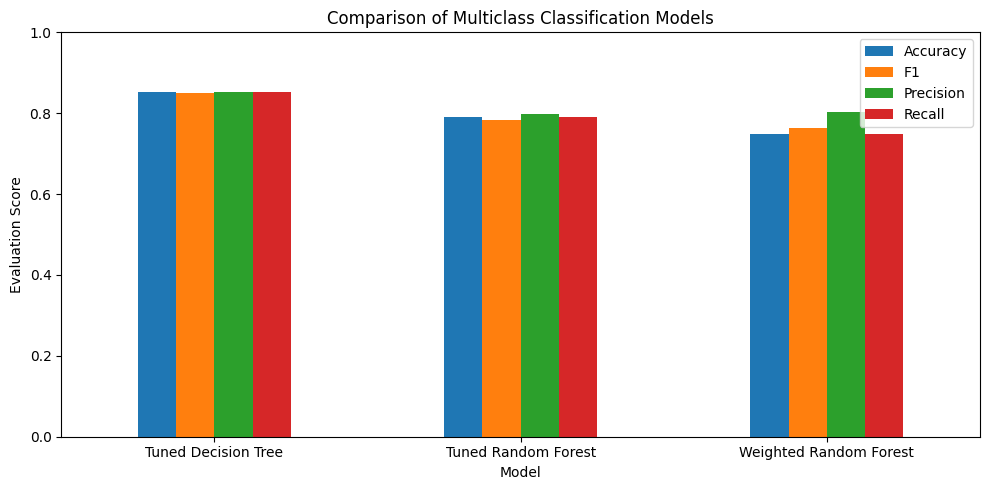

In [31]:
# Visual comparison of model performance

ax = model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylim(0, 1)
plt.ylabel("Evaluation Score")
plt.title("Comparison of Multiclass Classification Models")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Student 2: [Name - Student ID] — Confusion Matrix


In [32]:
# Student 2: [Name - Student ID]

confusion_pd = confusion_df.toPandas()

matrix = (
    confusion_pd
    .pivot(index="label", columns="prediction", values="count")
    .fillna(0)
    .reindex(index=range(7), columns=range(7), fill_value=0)
)

matrix


prediction,0,1,2,3,4,5,6
label,,,,,,,
0,32579.0,9985.0,4.0,0.0,0.0,0.0,182.0
1,7325.0,48635.0,355.0,1.0,18.0,55.0,28.0
2,0.0,747.0,6287.0,19.0,0.0,93.0,0.0
3,0.0,0.0,204.0,325.0,0.0,8.0,0.0
4,11.0,1529.0,53.0,0.0,230.0,0.0,0.0
5,0.0,992.0,1387.0,16.0,0.0,1107.0,0.0
6,1207.0,28.0,0.0,0.0,0.0,0.0,2815.0


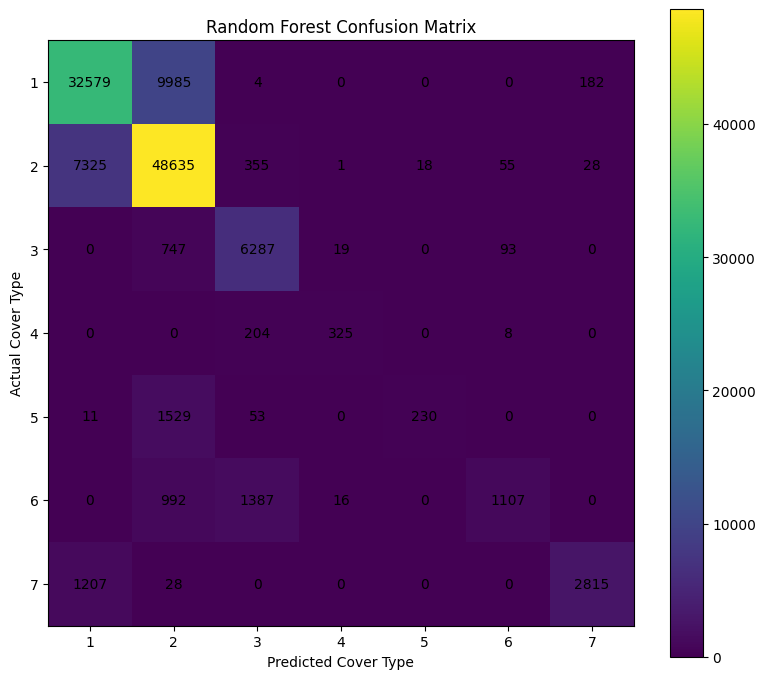

In [33]:
# Confusion matrix visualisation

matrix_values = matrix.values

fig, ax = plt.subplots(figsize=(8, 7))
img = ax.imshow(matrix_values)

ax.set_xlabel("Predicted Cover Type")
ax.set_ylabel("Actual Cover Type")
ax.set_title("Random Forest Confusion Matrix")

ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(range(1, 8))
ax.set_yticklabels(range(1, 8))

for i in range(matrix_values.shape[0]):
    for j in range(matrix_values.shape[1]):
        ax.text(
            j, i, int(matrix_values[i, j]),
            ha="center", va="center"
        )

plt.colorbar(img)
plt.tight_layout()
plt.show()


In [34]:
# Feature importance from the tuned Random Forest

feature_importances = best_rf_model.featureImportances.toArray()

importance_pd = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": feature_importances
}).sort_values("Importance", ascending=False)

importance_pd.head(15)


,Feature,Importance
0,Elevation,0.353587
13,Wilderness_Area4,0.085186
5,Horizontal_Distance_To_Roadways,0.064356
9,Horizontal_Distance_To_Fire_Points,0.051687
35,Soil_Type22,0.033805
17,Soil_Type4,0.029640
23,Soil_Type10,0.026630
3,Horizontal_Distance_To_Hydrology,0.026347
52,Soil_Type39,0.024951
51,Soil_Type38,0.023684


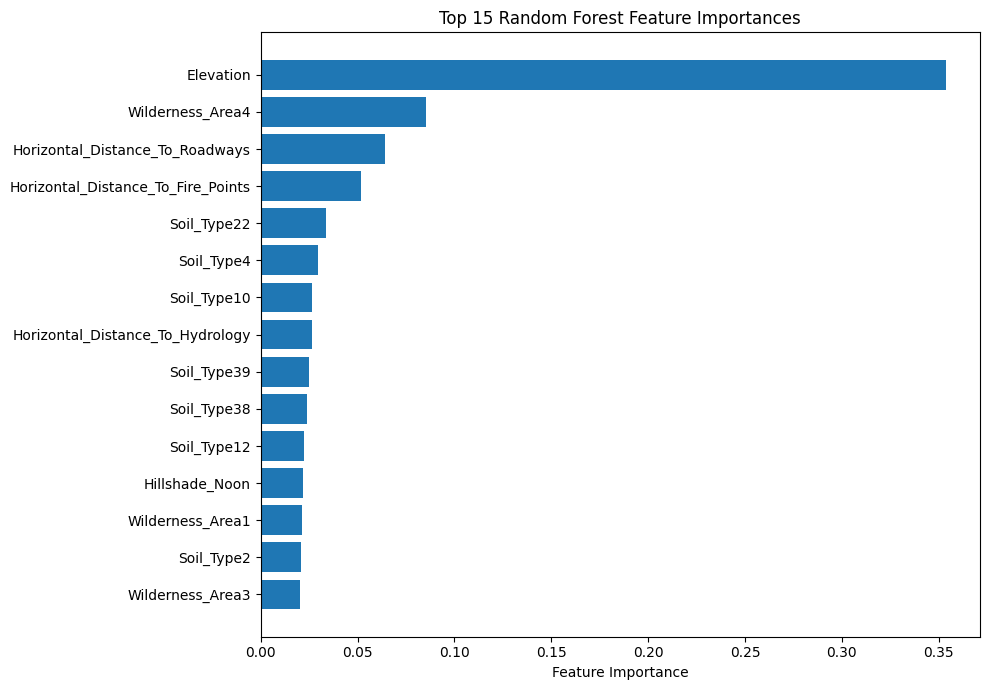

In [35]:
# Plot top 15 feature importances

top15 = importance_pd.head(15)

plt.figure(figsize=(10, 7))
plt.barh(
    top15["Feature"][::-1],
    top15["Importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()


### Feature-Importance Interpretation

Feature importance indicates which variables contributed most strongly to the Random Forest's predictive decisions. It should not be interpreted as proof that a variable causes a particular forest cover type.


In [36]:
# Bias-variance analysis at different tree depths

bias_variance_results = []

for depth in [5, 10, 20]:
    temp_rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=50,
        maxDepth=depth,
        seed=42
    )

    temp_model = temp_rf.fit(train_df)

    train_predictions = temp_model.transform(train_df)
    test_predictions = temp_model.transform(test_df)

    accuracy_eval = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    )

    train_accuracy = accuracy_eval.evaluate(train_predictions)
    test_accuracy = accuracy_eval.evaluate(test_predictions)

    bias_variance_results.append({
        "MaxDepth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

bias_variance_pd = pd.DataFrame(bias_variance_results)
bias_variance_pd


,MaxDepth,Training Accuracy,Testing Accuracy
0,5,0.676581,0.677780
1,10,0.738149,0.736872
2,20,0.853214,0.842357


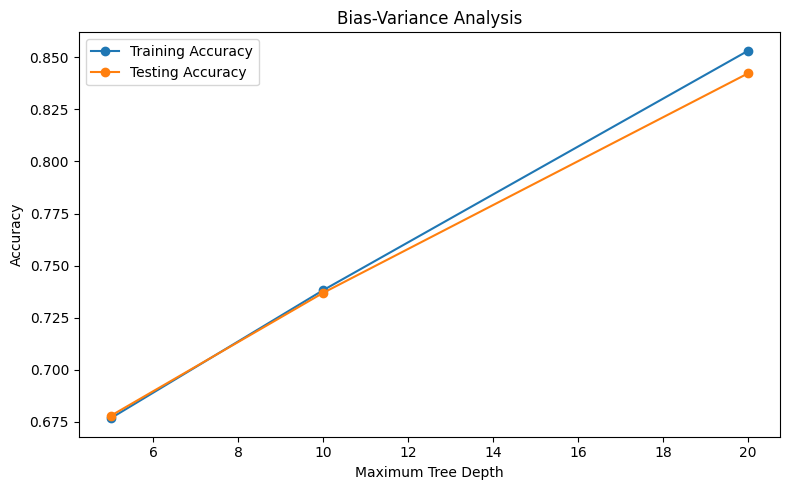

In [37]:
# Bias-variance visualisation

plt.figure(figsize=(8, 5))

plt.plot(
    bias_variance_pd["MaxDepth"],
    bias_variance_pd["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    bias_variance_pd["MaxDepth"],
    bias_variance_pd["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Analysis")
plt.legend()
plt.tight_layout()
plt.show()


### Bias and Variance Discussion

A shallow tree depth may result in **high bias (underfitting)** when both training and test performance are low. Increasing tree depth increases model complexity and may improve fit. However, if training accuracy becomes substantially higher than testing accuracy, this indicates increasing **variance (overfitting)**.

Random Forest reduces variance by aggregating predictions across multiple decision trees. The final model is therefore selected using validation performance rather than training accuracy alone.


# Task 7 - LSEP Considerations (10 marks)


## Student 1: Ethical Issue — Algorithmic Bias

The primary ethical issue investigated is algorithmic bias resulting from class imbalance. The Forest CoverType dataset does not contain equal numbers of observations for all seven forest classes. Models optimised only for overall accuracy may therefore prioritise majority classes while producing weaker predictions for minority forest categories.

To mitigate this issue, the analysis reports F1-score, precision, recall and class-specific results in addition to overall accuracy. The confusion matrix is also used to identify classes that are systematically misclassified. An additional class-weighted Random Forest is trained to examine whether minority-class treatment can be improved.

Model results should not be interpreted as infallible environmental decisions. Where such models are used in real environmental-management applications, predictions should support rather than replace appropriate professional and ecological expertise.


## Student 2: Professional Issue — Reproducibility and Transparency

A major professional requirement in machine learning is reproducibility. Results that change unpredictably between executions can reduce confidence in an analytics system and make comparison between models unreliable.

For this project, explicit random seeds are defined for train-test splitting, Decision Tree construction, Random Forest training and model optimisation. The final Random Forest configuration is additionally executed across five defined seeds. Mean performance and standard deviation are reported to demonstrate both predictive ability and model stability.

All preprocessing operations, selected attributes, hyperparameters and evaluation metrics are documented in the notebook. No model results should be entered manually; reported metrics must be generated directly from executable PySpark code. This improves transparency, auditability and professional accountability.


## Student 3: Legal Issue — Dataset Use and Attribution

[Use this section if the group has a third member.]

The dataset should be used in accordance with the terms and attribution requirements of its original source. The report should clearly identify the Forest CoverType dataset and retain appropriate source acknowledgement. The group should avoid presenting the dataset as its own collected material and should not remove provenance information when sharing the analysis.

The analysis does not contain personal data, but responsible data-governance principles still apply. The source, purpose of use, processing steps and limitations should be documented so that the use of the dataset is transparent and traceable.


## Student 4: Social Issue — Responsible Environmental Interpretation

[Use this section if the group has a fourth member.]

Machine-learning predictions of forest cover may influence how users interpret environmental conditions. Misclassification could lead to incorrect assumptions if predictions are treated as definitive observations rather than statistical estimates.

The project therefore reports model limitations and class-specific performance. In practical environmental applications, predictions should be combined with domain expertise, field observations and appropriate quality controls. This reduces the risk of over-reliance on automated classification and supports responsible use of machine-learning outputs.


## Overall Results and Discussion

**Complete this section only after all model cells have been executed.**

Report the actual generated values for:

- Tuned Decision Tree accuracy, F1, weighted precision and weighted recall.
- Tuned Random Forest accuracy, F1, weighted precision and weighted recall.
- Weighted Random Forest results.
- Five-run mean ± standard deviation.
- Best Random Forest hyperparameters.
- Minority-class behaviour from per-class precision/recall.
- Most important predictor variables.
- Evidence of underfitting or overfitting from the bias-variance experiment.

Do not enter invented performance values. Interpret only the output generated by the notebook.


## Conclusion

**Complete this paragraph after executing the notebook and reviewing the actual outputs.**

The conclusion should state whether the Random Forest improved upon the Decision Tree baseline, whether the target performance level was achieved, how stable the model was across the five runs, how class imbalance affected performance, and what the main limitations and future improvements are.


# Report HTML template (5 marks)

The final report must be converted from the completed notebook into a single HTML file. Before conversion:

1. Replace all Group ID and student placeholders.
2. Run all cells from top to bottom.
3. Verify that all tables, graphs and model outputs are visible.
4. Remove any unnecessary error messages or temporary debugging cells.
5. Save the notebook using the required group filename.


In [38]:
# Install nbconvert if needed

!pip3 install nbconvert -q


In [39]:
# IMPORTANT:
# Change the filename below to the actual notebook filename before running.
#
# Example:
# !jupyter nbconvert --to html Group50_CRWK_CN7030_3.ipynb

# !jupyter nbconvert --to html Your_Group_ID_CRWK_CN7030.ipynb


In [ ]:
!jupyter nbconvert --to html Your_Group_ID_CRWK_CN7030.ipynb